In [1]:
import torch
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error

# === utils ===
from utils.model_utils import get_encoder, get_decoder
from utils.data_utils.load_data import load_dataset, extract_target_properties
from utils.evaluate_utils.load_paths import load_paths
from utils.evaluate_utils.normalization import compute_normalized_mse
from utils.evaluate_utils import visualize_latent as latent
from utils.evaluate_utils import visualize_output as output
from utils.evaluate_utils.sampling import *
from utils.evaluate_utils.load_models import *
from utils.evaluate_utils.error import compute_tensor_error
from utils.domain_scaling import denormalize_S, unpack_active
from utils.evaluate_utils.structure_constraints import enforce_theta_domain, filter_S_candidates


# === seed and device ===
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# === config ===
THETA_MODEL = True
TRIAL = 12
THETA_PATTERN = "001"
USE_FLOW = False
FLOW_TYPE = "realnvp"

# === paths ===
paths = load_paths(TRIAL, THETA_MODEL, THETA_PATTERN, USE_FLOW, FLOW_TYPE)
P_mean = np.load(paths["P_mean_path"])
P_std = np.load(paths["P_std_path"])
P_all, S_all, C_all = load_dataset(paths["DATA_PATH"])

# === load model + config ===
fNN = load_fNN_model()
config = load_config(paths["config_path"])
encoder = load_encoder(config, paths["encoder_path"], trial=TRIAL, device=device)
decoder = load_decoder(config, paths["decoder_path"], flow_type=FLOW_TYPE, trial=TRIAL, device=device)
LATENT_DIM = config["LATENT_DIM"]
active_idx = config["ACTIVE_IDX"]

✅ Loaded files from theta_001 for trial 12


✅ Loaded Max's forward model
✅ Loaded encoder from trial 12
✅ Loaded decoder from trial 12


/Users/ellielin/Desktop/dresden/inverse_design_spinodoids/spinodoid_cvae/utils/evaluate_utils/load_models.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_s

In [3]:
# === select target ===
target_index = 5
S_true = S_all[target_index].cpu().numpy()
P_true = P_all[target_index].unsqueeze(0).to(device)
C_true = C_all[target_index]

print(f"✅ Using target index {target_index}")
print(f"   - S_true: {np.round(S_true, 3)}")
print(f"   - P_true: {np.round(P_true.cpu().numpy(), 3)}")

# === evaluate surrogate fNN on S_true ===
S_true_tf = np.expand_dims(S_true, axis=(0, 1))  # (1, 1, 4)
C_fNN_true = fNN(S_true_tf).numpy().reshape(1, 3, 3, 3, 3)[0]

✅ Using target index 5
   - S_true: [ 0.     0.    38.692  0.858]
   - P_true: [[0.988 0.377 0.311 0.995 0.31  0.73  0.306 0.248 0.248]]


In [4]:
# === normalize P for decoder ===
P_norm = (P_true.cpu().numpy() - P_mean) / (P_std + 1e-8)
P_norm = torch.tensor(P_norm, dtype=torch.float32).to(device)

# === sample from decoder ===
S_hats_norm = get_S_hats(decoder, P_norm, LATENT_DIM, num_samples=1000, seed=SEED + target_index, device=device)

# === extract peaks from normalized S ===
S_hat_peaks_norm, bw = extract_peaks_with_bandwidth(S_hats_norm, use_auto_bandwidth=True, manual_bw=4.0, target_range=(5, 8))
S_hat_peaks_norm, probs, counts = sort_peaks_by_empirical_probability(S_hats_norm, S_hat_peaks_norm, bw)



❌ [Auto] Could not find a bandwidth that yields desired number of peaks.

✅ Sorted empirical probabilities for each peak:
  Peak 0: 1000 samples (1.000)


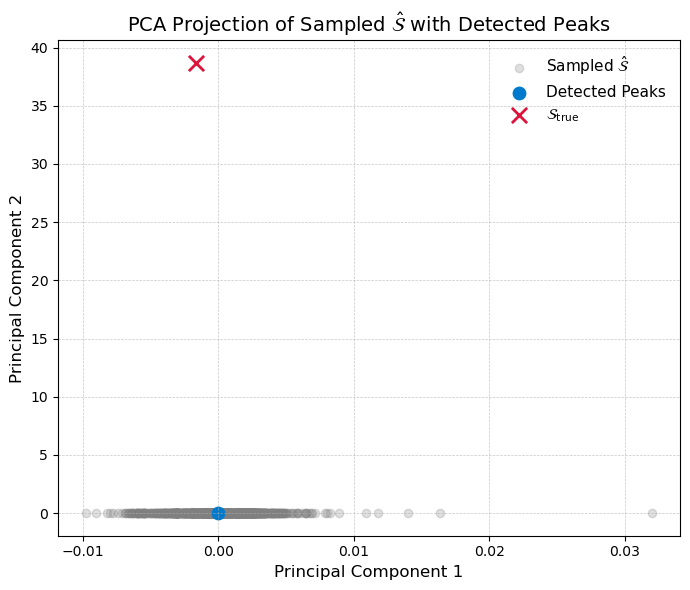

In [5]:
# === unpack + denormalize ===
S_hat_peaks_full = np.array([unpack_active(s, active_idx) for s in S_hat_peaks_norm])
S_hat_peaks_unnorm = np.array([denormalize_S(s) for s in S_hat_peaks_full])
S_hats_full = np.array([unpack_active(s, active_idx) for s in S_hats_norm])
S_hats_unnorm = np.array([denormalize_S(s) for s in S_hats_full])

# === enforce constraints ===
S_hat_peaks_unnorm = enforce_theta_domain(S_hat_peaks_unnorm)
S_hat_peaks_unnorm = filter_S_candidates(S_hat_peaks_unnorm)

# === visualize Ŝ space ===
output.plot_S_hat_space(S_hats_unnorm, S_true, S_hat_peaks_unnorm)


✅ Mean MSE across all peaks (unnormalized): 0.01469



Peak,||P-hat - P||,MSE
0,0.3636,0.014691


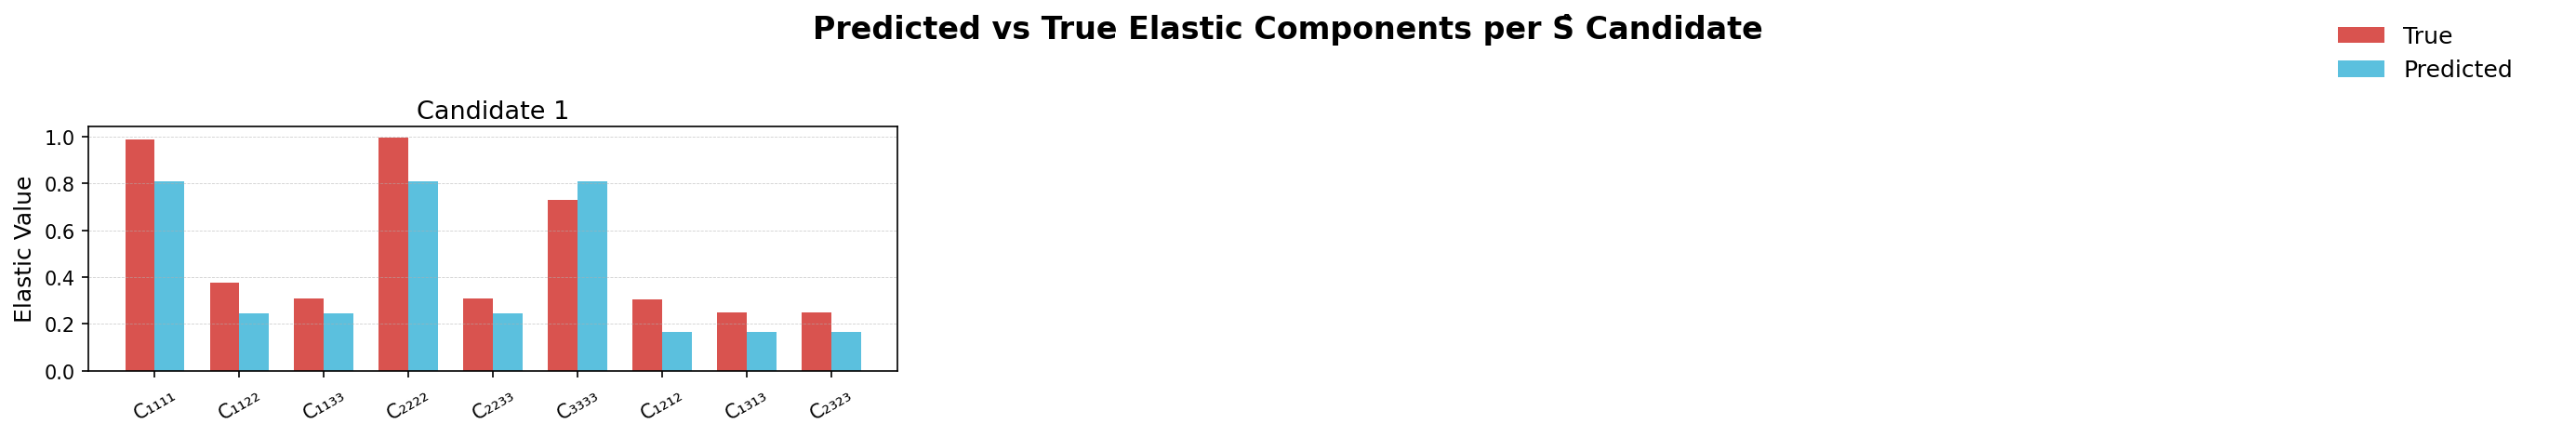

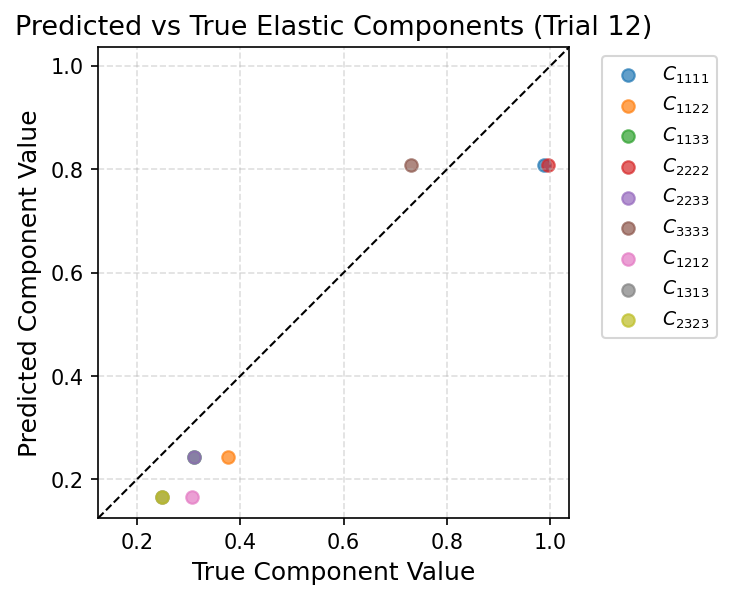

✅ Error (C_fNN_true vs C_true): 1.0662%
 - Ĉ_1 vs C_true: Error = 25.2483% — ❌ FAIL


In [6]:
# === evaluate P̂ using surrogate fNN ===
P_true_flat = np.array(P_true).flatten()
P_preds, errors, mses, df_peaks, C_preds = output.evaluate_peaks(S_hat_peaks_unnorm, P_true_flat, fNN)
output.plot_all_P_preds_vs_true(P_preds, P_true_flat)
output.plot_pred_vs_true_scatter(P_true_flat, P_preds, trial=TRIAL)

# === compare Ĉ tensors ===
error_fNN = compute_tensor_error(C_true, C_fNN_true)
print(f"✅ Error (C_fNN_true vs C_true): {error_fNN:.4%}")

for i, C_hat in enumerate(C_preds):
    err = compute_tensor_error(C_true, C_hat)
    print(f" - Ĉ_{i+1} vs C_true: Error = {err:.4%} — {'✅ PASS' if err < 0.08 else '❌ FAIL'}")

In [7]:
# === average MSE evaluation ===
df_mse = output.evaluate_avg_mse_per_target_pair(
    decoder=decoder,
    P_all=P_all,
    S_all=S_all,
    latent_dim=LATENT_DIM,
    fNN=fNN,
    P_mean_path=paths["P_mean_path"],
    P_std_path=paths["P_std_path"],
    S_mean_path=paths["S_mean_path"],
    S_std_path=paths["S_std_path"],
    bw=bw,
    N=20,
    seed=42,
    device=device
)

/Users/ellielin/Desktop/dresden/inverse_design_spinodoids/spinodoid_cvae/utils/evaluate_utils/visualize_output.py:23: SyntaxWarning: invalid escape sequence '\h'
  """


ValueError: operands could not be broadcast together with shapes (1,2) (4,) 